In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import illustris_python as il

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False

plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [31]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:

def running_percentiles(xdata, ydata, window_size, percentiles=[50], dx=0.1):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata[xdata>0]))/dx)
    
    
    bin_first = min(xdata[xdata>0]) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    
    running_percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        if i < window_size - 1:
            running_percentile_arr[i] = np.nan  # Not enough data points for the window
        else:   
            for ip, percentile in enumerate(percentiles):
                running_percentile_arr[ip][i] = np.percentile(ydata[bin_mask], q=percentile)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_percentile_arr



In [9]:
def read_data(sim_dir, data_type="cent"):
    if data_type == "cent":
        sim_data1 = np.loadtxt(f"{sim_dir}/sfr-halomass_central.txt")

        ihalo_sim1 =  sim_data1[:,0]
        mhalo_sim1 = sim_data1[:,1]
        sfr_sim1 = sim_data1[:,5]

        sim_data2 = np.loadtxt(f"{sim_dir}/sfr-cent_0sfr.txt")

        ihalo_sim2 =  sim_data2[:,0]
        mhalo_sim2 = sim_data2[:,1]
        sfr_sim2 = sim_data2[:,5]

        ihalo_sim3 = np.concatenate((ihalo_sim1,ihalo_sim2))
        mhalo_sim3 = np.concatenate((mhalo_sim1,np.round(mhalo_sim2,4)))
        sfr_sim3 = np.concatenate((sfr_sim1,sfr_sim2))
    elif data_type == "sat_sum":
        sim_data3 = np.loadtxt(f"{sim_dir}/sat_submass_sum_logM10.txt")
        ihalo_sim3 =  sim_data3[:,0]
        mhalo_sim3 = None
        sfr_sim3 = sim_data3[:,1]
        
    elif data_type == "group":
        sim_data3 = np.loadtxt(f"{sim_dir}/sfr-halomass_sum.txt")
        ihalo_sim3 =  sim_data3[:,0]
        mhalo_sim3 = sim_data3[:,1]
        sfr_sim3 = sim_data3[:,5]
        
    
    return ihalo_sim3, mhalo_sim3, sfr_sim3

In [5]:
snapnum = 40

In [6]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [7]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [8]:
h = 0.6774

In [9]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [10]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [11]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [12]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [13]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [14]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [15]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [16]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [17]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [173]:
cent_tot = np.sum(10**cent_sfrs)
print(cent_tot)
sat_tot = np.sum(10**sum_sfrs)
print(sat_tot)
gal_tot = cent_tot+sat_tot
print(gal_tot)
print(cent_tot/gal_tot)
print(sat_tot/gal_tot)

1275021.8548336534
299257.59911938873
1574279.4539530422
0.8099082101542088
0.19009178984579128


In [149]:
group_tot = np.sum(10**group_sfrs)
print(group_tot)

391319.44


In [150]:
gal_tot/group_tot

0.999336067607903

In [18]:
percentiles_list = [10, 25, 50, 75, 90]
window_size=0.2
dlogM= 0.1

In [19]:
bin_cents_cent, percentiles_cent = running_percentiles(mvir, cent_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)
bin_cents_sat, percentiles_sat = running_percentiles(mvir, sum_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)
bin_cents_group, percentiles_group = running_percentiles(mvir, group_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


In [26]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

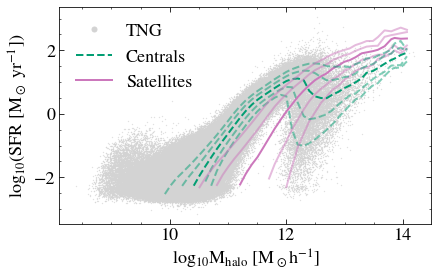

<Figure size 480x288 with 0 Axes>

In [21]:
plt.scatter(mvir, cent_sfrs, s=0.1, color="lightgrey", label="TNG")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    #plt.plot(bin_cents_group, percentiles_group[i], linestyle="dashed", color=color_list[0], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)

tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="TNG")
tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="Centrals")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="Satellites")
plt.legend(handles=[tng_scatter, tng,eagle], loc="upper left")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
#plt.ylim(-2,2.3)
plt.xlim()
plt.show()
plt.clf()

In [20]:
def running_fraction(xdata, ydata, window_size, lower_lim = -3, dx=0.1):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata[xdata>0]))/dx)
    
    bin_first = min(xdata[xdata>0]) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    running_frac_arr = np.zeros_like(bins, dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        #lim_mask = ydata[bin_mask] < lower_lim ????
        lim_mask = ydata[bin_mask] > lower_lim
        if i < window_size - 1:
            running_frac_arr[i] = np.nan  # Not enough data points for the window
        else:   
            running_frac_arr[i] = np.sum(lim_mask)/np.sum(bin_mask)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_frac_arr



In [21]:
bin_cents_frac_cent, cent_frac = running_fraction(mvir, cent_sfrs, window_size,lower_lim = -5, dx=dlogM)

In [22]:
bin_cents_frac_sat, sat_frac = running_fraction(mvir, sum_sfrs, window_size,lower_lim = -5, dx=dlogM)

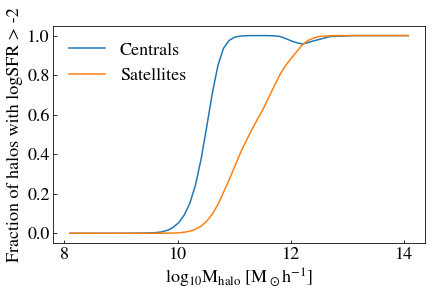

In [84]:
plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals")
plt.plot(bin_cents_frac_sat, 1-sat_frac, label="Satellites")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"Fraction of halos with logSFR > -2")
plt.legend()

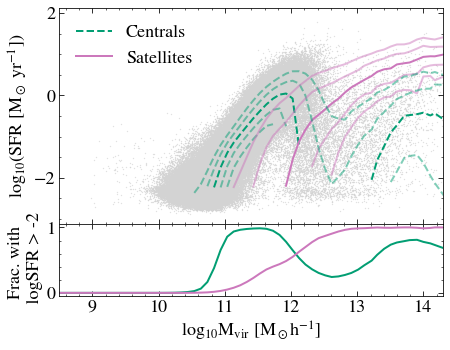

<Figure size 480x288 with 0 Axes>

In [77]:
figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))

plt.scatter(mvir, cent_sfrs, s=0.1, color="lightgrey", label="Centrals")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    #plt.plot(bin_cents_group, percentiles_group[i], linestyle="dashed", color=color_list[0], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)

tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="Centrals")
cent_leg = Line2D([],[], linestyle="dashed", color=color_list[1], label="Centrals")
sat_leg = Line2D([],[], linestyle="solid", color=color_list[2], label="Satellites")
plt.legend(handles=[cent_leg, sat_leg], loc="upper left")
#plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

plt.xlim(8.5, 14.3)

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals", color=color_list[1])
plt.plot(bin_cents_frac_sat, 1-sat_frac, label="Satellites", color=color_list[2])
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("Frac. with \n logSFR > -2")
#plt.savefig("../figures/sfr-mvir_cent_sat.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

In [23]:
bin_cents_frac_group, group_frac = running_fraction(mvir, group_sfrs, window_size,lower_lim = -5, dx=dlogM)

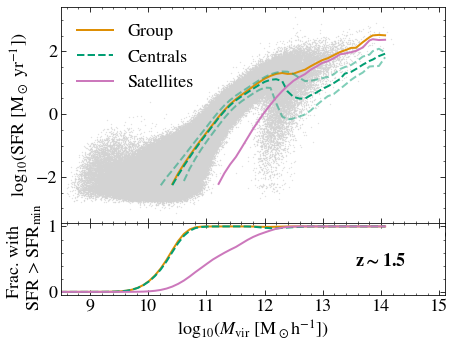

<Figure size 480x288 with 0 Axes>

In [57]:
figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))

plt.scatter(mvir, group_sfrs, s=0.1, color="lightgrey", label="Group")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
        plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)
    elif i == 1 or i == 3:
        
        alpha = 0.5
        #plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        #plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)
tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="Group")
group = Line2D([],[], linestyle="solid", color=color_list[0], label="Group")
cent = Line2D([],[], linestyle="dashed", color=color_list[1], label="Centrals")
sat_leg = Line2D([],[], linestyle="solid", color=color_list[2], label="Satellites")
plt.legend(handles=[group, cent, sat_leg], loc="upper left")
#plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

plt.xlim(8.5, 15.1)

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

# plt.plot(bin_cents_frac_group, 1-group_frac, label="Group", color=color_list[0]) # 1 minus to get fraction greater than sfr lim
# plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals", linestyle="dashed", color=color_list[1])
# plt.plot(bin_cents_frac_sat, 1-sat_frac, label="Satellites", color=color_list[2])

plt.plot(bin_cents_frac_group, group_frac, label="Group", color=color_list[0]) # 1 minus to get fraction greater than sfr lim
plt.plot(bin_cents_frac_cent, cent_frac, label="Centrals", linestyle="dashed", color=color_list[1])
plt.plot(bin_cents_frac_sat, sat_frac, label="Satellites", color=color_list[2])

plt.xlabel(r"log$_{10}$$(M_{\rm vir}$ [M$_\odot$h$^{-1}$])")
#plt.ylabel("Frac. with \n logSFR > -2")
plt.ylabel("Frac. with \n SFR > SFR$_{\mathrm{min}}$")
ax = plt.gca()
ax.annotate("$\mathbf{z \sim 1.5}$", (0.9,0.4), xycoords="axes fraction", ha="right", weight="bold")
#plt.savefig("../figures/sfr-mvir_median_z3.png", format="png", bbox_inches="tight", dpi=300)

plt.show()
plt.clf()

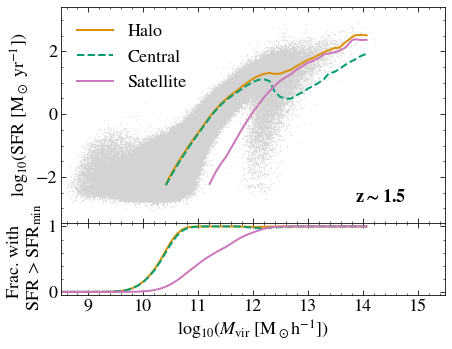

<Figure size 480x288 with 0 Axes>

In [59]:
figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))

plt.scatter(mvir, group_sfrs, s=0.1, color="lightgrey", label="Group")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
        plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)
    elif i == 1 or i == 3:
        
        alpha = 0.5
        #plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        #plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        #plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)
tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="Group")
group = Line2D([],[], linestyle="solid", color=color_list[0], label="Halo")
cent = Line2D([],[], linestyle="dashed", color=color_list[1], label="Central")
sat_leg = Line2D([],[], linestyle="solid", color=color_list[2], label="Satellite")
plt.legend(handles=[group, cent, sat_leg], loc="upper left")
#plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

plt.xlim(8.5, 15.5)
ax = plt.gca()
ax.annotate("$\mathbf{z \sim 1.5}$", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

# plt.plot(bin_cents_frac_group, 1-group_frac, label="Group", color=color_list[0]) # 1 minus to get fraction greater than sfr lim
# plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals", linestyle="dashed", color=color_list[1])
# plt.plot(bin_cents_frac_sat, 1-sat_frac, label="Satellites", color=color_list[2])
ax = plt.gca()
ax.plot(bin_cents_frac_group, group_frac, label="Halo", color=color_list[0]) # 1 minus to get fraction greater than sfr lim
ax.plot(bin_cents_frac_cent, cent_frac, label="Central", linestyle="dashed", color=color_list[1])
ax.plot(bin_cents_frac_sat, sat_frac, label="Satellite", color=color_list[2])

plt.xlabel(r"log$_{10}$$ (M_{\rm vir}$ [M$_\odot$h$^{-1}$])")
#plt.ylabel("Frac. with \n logSFR > -2")
plt.ylabel("Frac. with \n SFR > SFR$_{\mathrm{min}}$")

#plt.savefig("../figures/sfr-mvir_median_z3.png", format="png", bbox_inches="tight", dpi=300)
ax.set_xlim(8.5, 15.5)
#plt.savefig("figures/", format="pdf", bbox_inches="tight")
#plt.savefig("../figures/sfr-mvir_median_z1.5.png", format="png", bbox_inches="tight", dpi=300)

plt.show()
plt.clf()

[Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')]


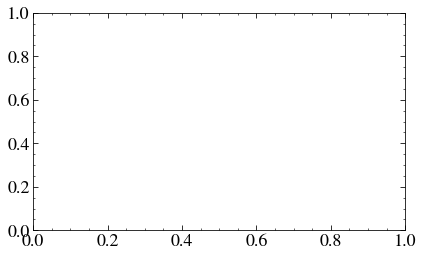

In [29]:
print(bin_cents_frac_group[28:])
print(group_frac[28:])

[10.8105011  10.91042805 11.01046658 11.1091814  11.20835209 11.30861092
 11.40765476 11.5058012  11.60468102 11.70485878 11.80204582 11.90389538
 12.00138283 12.1005249  12.19755268 12.30099869 12.39338303 12.49467182
 12.59751129 12.69237518 12.79245186 12.89244938 12.99388409 13.08650684
 13.18684006 13.29565525 13.37784672 13.48732948 13.57131386 13.68664837
 13.80112648 13.85756493 13.96310997 14.06963539]
[0.98671031 0.99647539 0.99931186 0.99983257 0.99993711 0.99996183
 1.         1.         0.99985945 0.99939167 0.99837169 0.9952901
 0.99279172 0.99311384 0.99467563 0.99727965 0.9985819  1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]


In [102]:
def running_number(xdata, ydata, window_size, lower_lim = -3, dx=0.1):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata[xdata>0]))/dx)
    
    bin_first = min(xdata[xdata>0]) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    running_frac_arr = np.zeros_like(bins, dtype=float)
    ntot_arr = np.zeros_like(bins, dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        lim_mask = ydata[bin_mask] > lower_lim
        if i < window_size - 1:
            running_frac_arr[i] = np.nan  # Not enough data points for the window
            ntot_arr[i] = np.nan
        else:   
            running_frac_arr[i] = np.sum(lim_mask)#/np.sum(bin_mask)
            ntot_arr[i] = np.sum(bin_mask)
            
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_frac_arr, ntot_arr



In [77]:
i = 30
print(bin_cents_number_group[i])
print(group_number[i])

11.010466575622559
65.0


In [78]:
print(window_size)

0.2


In [79]:
print(dlogM)

0.1


In [103]:
bin_cents_number_group, group_number, group_ntot = running_number(mvir, group_sfrs, window_size,lower_lim = -5, dx=dlogM)

In [90]:
bin_cents_number_cent, cent_number = running_number(mvir, cent_sfrs, window_size,lower_lim = -5, dx=dlogM)

In [91]:
bin_cents_number_sat, sat_number = running_number(mvir, sum_sfrs, window_size,lower_lim = -5, dx=dlogM)

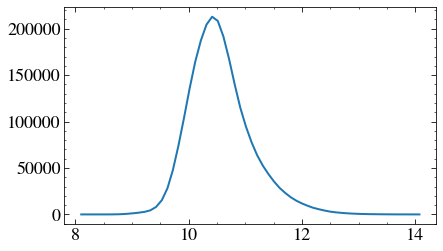

In [82]:
plt.plot(bin_cents_number_group, group_number)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


Text(0.5, 0, '$\\rm log_{10} $($M_{\\mathrm{vir}}$$\\rm[M_\\odot h^{-1}$])')

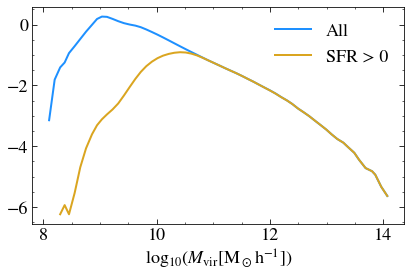

In [110]:
plt.plot(bin_cents_number_group, np.log10(group_ntot/(volume*window_size)), label="All", color="DodgerBlue")
plt.plot(bin_cents_number_group, np.log10(group_number/(volume*window_size)), label="SFR > 0", color="goldenrod")
plt.legend()
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


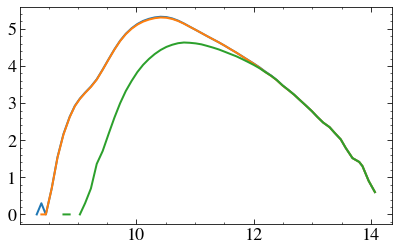

In [95]:
plt.plot(bin_cents_number_group, np.log10(group_number))
plt.plot(bin_cents_number_cent, np.log10(cent_number))
plt.plot(bin_cents_number_sat, np.log10(sat_number))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


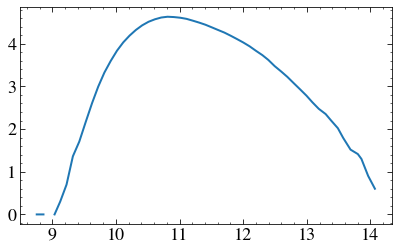

In [93]:
plt.plot(bin_cents_number_sat, np.log10(sat_number))

In [96]:
boxsize=205
volume = boxsize**3

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


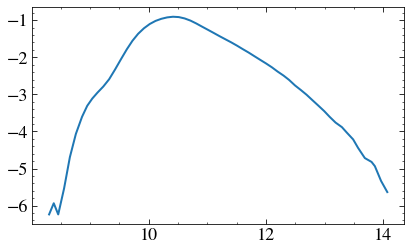

In [99]:
plt.plot(bin_cents_number_group, np.log10(group_number/(volume*window_size)))